## Data Preparation & Preprocessing

In [ ]:
import os
import zipfile
from google.colab import drive

# ==========================================
# 1. Mount Google Drive
# ==========================================
drive.mount('/content/drive', force_remount=True)

# ==========================================
# 2. Define Paths
# ==========================================
# Folder Name: 5100_glaucoma
# Zip Name:    glaucoma_dataset.zip
drive_zip_path = '/content/drive/MyDrive/5100_glaucoma/glaucoma_dataset.zip'

# Local path where we unzip files (fast training)
local_data_path = '/content/5100_glaucoma_data'

# ==========================================
# 3. Check and Unzip
# ==========================================
if os.path.exists(drive_zip_path):
    print(f"✅ FOUND ZIP: {drive_zip_path}")

    # Check if we already unzipped it to save time
    if not os.path.exists(local_data_path):
        print(f"📂 Unzipping data to {local_data_path}... (Please wait)")

        try:
            with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
                zip_ref.extractall(local_data_path)
            print("✅ SUCCESS! Data is ready for use.")

        except zipfile.BadZipFile:
            print("❌ ERROR: The zip file appears corrupted. Please check the upload.")
    else:
        print("Data already unzipped locally. Ready to go!")

else:
    print(f"❌ ERROR: Could not find file at: {drive_zip_path}")

Mounted at /content/drive
✅ FOUND ZIP: /content/drive/MyDrive/5100_glaucoma/glaucoma_dataset.zip
📂 Unzipping data to /content/5100_glaucoma_data... (Please wait)
✅ SUCCESS! Data is ready for use.


### Visual Integrity Check

✅ Found 1020 Images and 1020 Masks.

🔍 ANALYSIS of image_1338.png:
Unique pixel values found in mask: [0 1 2]
 Interpretation:
  • 0 = Background
  • 1 = Optic Disc (likely)
  • 2 = Optic Cup (likely)


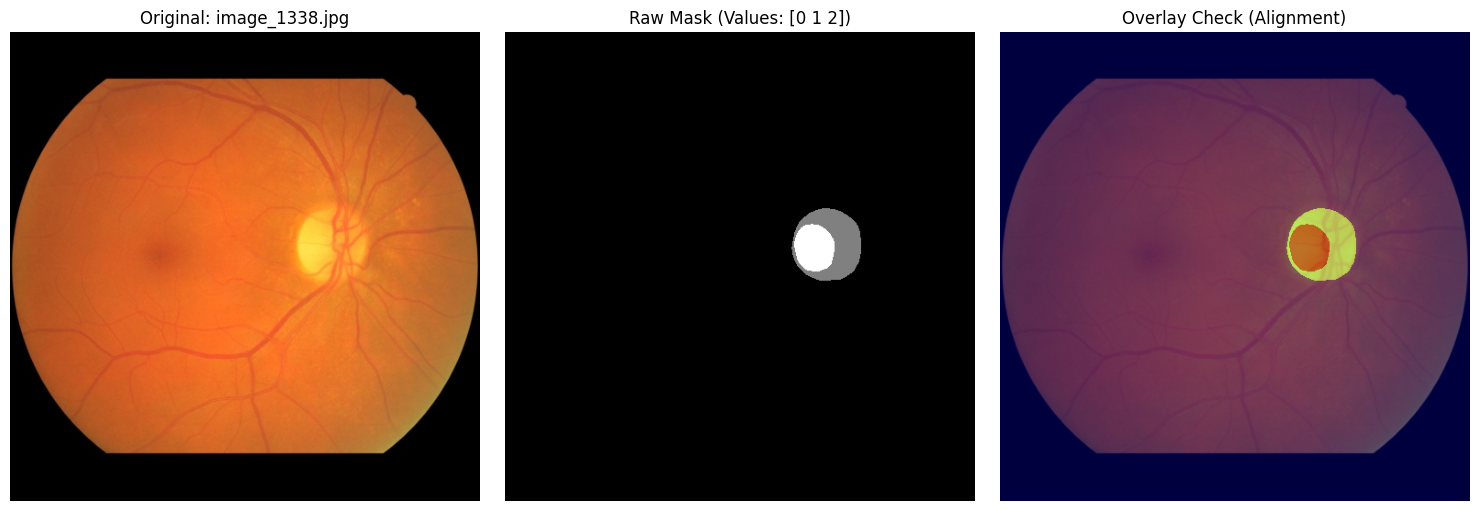

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Setup Paths
# We use the '5100_glaucoma_data' path you created
base_path = '/content/5100_glaucoma_data/G1020'
img_dir = os.path.join(base_path, 'Images_Square')
mask_dir = os.path.join(base_path, 'Masks_Square')

# 2. Get File Lists
img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
# Note: In G1020, masks usually have the same name but .png extension
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])

print(f"✅ Found {len(img_files)} Images and {len(mask_files)} Masks.")

# 3. Pick a Random Sample to Visualize
idx = random.randint(0, len(img_files)-1)
img_name = img_files[idx]
mask_name = img_name.replace('.jpg', '.png')

img_path = os.path.join(img_dir, img_name)
mask_path = os.path.join(mask_dir, mask_name)

# 4. Load Data
# Image: RGB
image = Image.open(img_path).convert('RGB')
# Mask: Grayscale (L) - this is crucial to see the integer values
mask = Image.open(mask_path).convert('L')

# Convert to numpy for analysis
img_np = np.array(image)
mask_np = np.array(mask)

# 5. Step 2: Pixel Value Audit (The "Integer Test")
unique_values = np.unique(mask_np)
print(f"\n🔍 ANALYSIS of {mask_name}:")
print(f"Unique pixel values found in mask: {unique_values}")
print(" Interpretation:")
if len(unique_values) == 3:
    print(f"  • {unique_values[0]} = Background")
    print(f"  • {unique_values[1]} = Optic Disc (likely)")
    print(f"  • {unique_values[2]} = Optic Cup (likely)")
else:
    print(f"  ⚠️ Unexpected number of classes: {len(unique_values)}. Values: {unique_values}")

# 6. Step 1: Visualization (The "Overlay" Test)
plt.figure(figsize=(15, 5))

# Plot A: Original Image
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original: {img_name}")
plt.axis('off')

# Plot B: The Raw Mask
plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap='gray')
plt.title(f"Raw Mask (Values: {unique_values})")
plt.axis('off')

# Plot C: The Overlay (Yellow=Cup, Blue=Disc)
plt.subplot(1, 3, 3)
plt.imshow(img_np)
# Create a color mask overlay
plt.imshow(mask_np, cmap='jet', alpha=0.5)
plt.title("Overlay Check (Alignment)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Split the data

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

# ==========================================
# 1. The Dataset Class
# ==========================================
class GlaucomaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # Sort to ensure alignment
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load File Paths
        img_name = self.images[idx]
        mask_name = img_name.replace('.jpg', '.png')

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # Load Data
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") # Load as integers (0,1,2)

        # Apply Transforms
        # Note: We must apply the SAME random transform (flip/rotate) to both!
        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask

# ==========================================
# 2. Transform Logic (Augmentation)
# ==========================================
class DualTransform:
    """Applies the same transforms to both Image and Mask"""
    def __init__(self, mode='train'):
        self.mode = mode

    def __call__(self, image, mask):
        # 1. Resize (Mandatory)
        # NEAREST is crucial for masks to keep values 0,1,2 (not 1.5)
        image = TF.resize(image, (512, 512), interpolation=transforms.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (512, 512), interpolation=transforms.InterpolationMode.NEAREST)

        if self.mode == 'train':
            # 2. Random Horizontal Flip
            if np.random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # 3. Random Rotation (small angles)
            angle = np.random.uniform(-30, 30)
            image = TF.rotate(image, angle, interpolation=transforms.InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=transforms.InterpolationMode.NEAREST)

        # 4. To Tensor
        image = TF.to_tensor(image) # Scales to [0, 1]

        # Custom ToTensor for Mask (Keep as Long Integer 0,1,2)
        mask = np.array(mask)
        mask = torch.from_numpy(mask).long() # Values stay 0, 1, 2

        # 5. Normalize Image (ImageNet stats)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        return image, mask

# ==========================================
# 3. Create the Split (60/20/20)
# ==========================================
# Paths
base_path = '/content/5100_glaucoma_data/G1020'
img_dir = os.path.join(base_path, 'Images_Square')
mask_dir = os.path.join(base_path, 'Masks_Square')

# Initialize Full Dataset
full_dataset = GlaucomaDataset(img_dir, mask_dir, transform=None)

# Calculate Split Sizes
total_size = len(full_dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size # <--- We use this variable below

# Perform Random Split
# FIX: Use [train_size, val_size, test_size] NOT test_set
train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Assign Transforms
train_set.dataset.transform = DualTransform(mode='train')
val_set.dataset.transform = DualTransform(mode='val')
test_set.dataset.transform = DualTransform(mode='val')

# Create DataLoaders
BATCH_SIZE = 2
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data Pipeline Ready!")
print(f"   Train: {len(train_set)} images")
print(f"   Val:   {len(val_set)} images")
print(f"   Test:  {len(test_set)} images")

# Final Check: Grab one batch
images, masks = next(iter(train_loader))
print(f"\nTensor Shapes Check:")
print(f"   Images: {images.shape} (Should be [8, 3, 512, 512])")
print(f"   Masks:  {masks.shape}  (Should be [8, 512, 512])")

✅ Data Pipeline Ready!
   Train: 612 images
   Val:   204 images
   Test:  204 images

Tensor Shapes Check:
   Images: torch.Size([2, 3, 512, 512]) (Should be [8, 3, 512, 512])
   Masks:  torch.Size([2, 512, 512])  (Should be [8, 512, 512])


## Model Architecture & Training

### 📝 Model 1: Basic U-Net (Lightweight Baseline)

### Architecture
- **Channel Progression:** 32 → 64 → 128 → 256 → 512 (5 levels)
- **Parameters:** ~7.8M (lightest)
- **Skip Connections:** Basic concatenation
- **Upsampling:** Transposed convolutions (learnable)

### Training Strategy
```
Loss: CrossEntropyLoss(weight=[1.0, 2.0, 20.0])
Learning Rate: 1e-4
Strategy: Aggressive weighting to force attention on cup class
```





In [ ]:
import torch
import torch.nn as nn

# ==========================================
# MODEL 1: Basic U-Net Architecture
# ==========================================

class DoubleConv_Model1(nn.Module):
    """Double convolution block for Model 1"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet_Model1(nn.Module):
    """Basic U-Net with lighter architecture (32->512 channels)"""
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv_Model1(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv_Model1(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv_Model1(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv_Model1(128, 256)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv_Model1(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv4 = DoubleConv_Model1(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv_Model1(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv_Model1(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv1 = DoubleConv_Model1(64, 32)

        self.out_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        c1 = self.down1(x); p1 = self.pool1(c1)
        c2 = self.down2(p1); p2 = self.pool2(c2)
        c3 = self.down3(p2); p3 = self.pool3(c3)
        c4 = self.down4(p3); p4 = self.pool4(c4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder with skip connections
        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c4 = self.conv4(u4)

        u3 = self.up3(c4)
        u3 = torch.cat([u3, c3], dim=1)
        c3 = self.conv3(u3)

        u2 = self.up2(c3)
        u2 = torch.cat([u2, c2], dim=1)
        c2 = self.conv2(u2)

        u1 = self.up1(c2)
        u1 = torch.cat([u1, c1], dim=1)
        c1 = self.conv1(u1)

        out = self.out_conv(c1)
        return out

# Test Model 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = UNet_Model1(in_channels=3, num_classes=3).to(device)
dummy_input = torch.randn(1, 3, 512, 512).to(device)
output = model1(dummy_input)
print(f"✅ Model 1 (Basic U-Net) - Output Shape: {output.shape}")

✅ Model 1 (Basic U-Net) - Output Shape: torch.Size([1, 3, 512, 512])


### 📝 Model 2: Custom Deep U-Net (Architectural Depth)

### Architecture
- **Channel Progression:** 64 → 128 → 256 → 512 → 1024 (5 levels, deeper)
- **Parameters:** ~31M (4x heavier than Model 1)
- **Skip Connections:** Advanced with automatic padding
- **Upsampling:** Bilinear interpolation (optional) + transposed convolutions

### Training Strategy
```
Loss: CrossEntropyLoss(weight=[1.0, 2.0, 20.0])
Learning Rate: 1e-4
Early Stopping: patience=10 epochs
Strategy: Same aggressive weighting as Model 1
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# MODEL 2: Custom Deep U-Net Architecture
# ==========================================

class DoubleConv_Model2(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down_Model2(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv_Model2(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up_Model2(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv_Model2(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv_Model2(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Match shapes with padding if needed
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv_Model2(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet_Model2(nn.Module):
    """Deep U-Net with advanced skip connections (64->1024 channels)"""
    def __init__(self, n_channels=3, n_classes=3, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv_Model2(n_channels, 64)
        self.down1 = Down_Model2(64, 128)
        self.down2 = Down_Model2(128, 256)
        self.down3 = Down_Model2(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down_Model2(512, 1024 // factor)
        self.up1 = Up_Model2(1024, 512 // factor, bilinear)
        self.up2 = Up_Model2(512, 256 // factor, bilinear)
        self.up3 = Up_Model2(256, 128 // factor, bilinear)
        self.up4 = Up_Model2(128, 64, bilinear)
        self.outc = OutConv_Model2(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# Test Model 2
model2 = UNet_Model2(n_channels=3, n_classes=3).to(device)
output = model2(dummy_input)
print(f"✅ Model 2 (Custom Deep U-Net) - Output Shape: {output.shape}")

✅ Model 2 (Custom Deep U-Net) - Output Shape: torch.Size([1, 3, 512, 512])


### 📝 Model 3: SMP ResNet34 U-Net (Transfer Learning Powerhouse)

### Architecture
- **Encoder:** ResNet34 backbone (pre-trained on ImageNet)
- **Decoder:** Standard U-Net decoder
- **Parameters:** ~24M
- **Skip Connections:** Built-in from segmentation_models_pytorch
- **Initialization:** ImageNet weights (1.2M images, 1000 classes)

### Training Strategy
```
Loss: Combined = 0.5 * CrossEntropy([1, 5, 10]) + 0.5 * Dice
Learning Rate: 5e-5 (lower to preserve pre-trained features)
Strategy:
  - CrossEntropy: Pixel-wise classification
  - Dice Loss: Overlap optimization (directly targets IoU)
```


In [ ]:
!pip install -q segmentation-models-pytorch

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# ==========================================
# MODEL 3: SMP U-Net with ResNet34 Encoder
# ==========================================

class CombinedLoss_Model3(nn.Module):
    """Hybrid loss combining CrossEntropy and Dice Loss"""
    def __init__(self, class_weights, weight_ce=0.5, weight_dice=0.5):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        self.dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=False)
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice

    def forward(self, y_pred, y_true):
        ce = self.ce_loss(y_pred, y_true)
        dice = self.dice_loss(y_pred, y_true)
        return self.weight_ce * ce + self.weight_dice * dice

# Initialize Model 3 with ImageNet pre-trained weights
model3 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3,
).to(device)

# Test Model 3
output = model3(dummy_input)
print(f"✅ Model 3 (SMP ResNet34 U-Net) - Output Shape: {output.shape}")
print("✅ Using ImageNet pre-trained weights")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ Model 3 (SMP ResNet34 U-Net) - Output Shape: torch.Size([1, 3, 512, 512])
✅ Using ImageNet pre-trained weights


### Shared Metric Functions

In [ ]:
# @title
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, confusion_matrix, cohen_kappa_score

# ==========================================
# Shared Metric Functions (All Models)
# ==========================================

def dice_coeff(pred_mask, true_mask, num_classes=3):
    """Calculates Dice Coefficient for classes 1 and 2 (Disc and Cup)"""
    probs = F.softmax(pred_mask, dim=1)
    dice_scores = []

    for class_idx in range(1, num_classes):
        p = probs[:, class_idx, :, :]
        t = (true_mask == class_idx).float()
        intersection = (p * t).sum()
        union = p.sum() + t.sum()
        score = (2. * intersection + 1e-6) / (union + 1e-6)
        dice_scores.append(score.item())

    return sum(dice_scores) / len(dice_scores)


def calculate_vertical_cdr(mask_pred, img_size=256):
    """Calculates vertical Cup-to-Disc Ratio (CDR)"""
    disc_mask = (mask_pred == 1) | (mask_pred == 2)
    cup_mask = (mask_pred == 2)

    if not np.any(disc_mask):
        return 0.0
    disc_coords = np.where(disc_mask)
    disc_height = np.max(disc_coords[0]) - np.min(disc_coords[0])

    if not np.any(cup_mask) or disc_height == 0:
        return 0.0
    cup_coords = np.where(cup_mask)
    cup_height = np.max(cup_coords[0]) - np.min(cup_coords[0])

    cdr = cup_height / disc_height
    return cdr

print("✅ Shared metric functions defined")

✅ Shared metric functions defined


### Training Function for Model 1 & Model 2

In [ ]:
import torch.optim as optim
from tqdm import tqdm

# ==========================================
# Training Function for Model 1 and Model 2
# ==========================================

def train_model_1_2(model, model_name, train_loader, val_loader,
                    epochs=50, learning_rate=1e-4, patience=10):
    """
    Training function for Model 1 and Model 2 (aggressive class weighting)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Aggressive class weights [Background, Disc, Cup]
    class_weights = torch.tensor([1.0, 2.0, 20.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    best_val_dice = 0.0
    epochs_no_improve = 0

    print(f"\n🚀 Starting {model_name} Training (Aggressive Weights [1.0, 2.0, 20.0])...")

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        loop = tqdm(train_loader, leave=True)

        for images, masks in loop:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_dice = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_dice += dice_coeff(outputs, masks)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)

        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)

        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

        # Model Saving and Early Stopping
        if avg_val_dice > best_val_dice:
            print(f"   🔥 New Best! ({best_val_dice:.4f} -> {avg_val_dice:.4f})")
            best_val_dice = avg_val_dice
            torch.save(model.state_dict(), f'best_{model_name.lower().replace(" ", "_")}.pth')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"🛑 Early Stopping triggered after {patience} epochs without improvement")
                break

    return history, best_val_dice

### Training Function for Model 3

In [ ]:
# ==========================================
# Training Function for Model 3 (SMP U-Net)
# ==========================================

def train_model_3(model, train_loader, val_loader,
                  class_weights_damped, epochs=50, learning_rate=5e-5, patience=10):
    """
    Training function for Model 3 (Hybrid loss with lower learning rate)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Combined loss (CrossEntropy + Dice)
    criterion = CombinedLoss_Model3(
        class_weights=class_weights_damped,
        weight_ce=0.5,
        weight_dice=0.5
    )
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
    best_val_dice = 0.0
    epochs_no_improve = 0

    print(f"\n🚀 Starting Model 3 Training (Combined Loss + ImageNet Weights)...")
    print(f"   Class Weights: {class_weights_damped.cpu().numpy()}")
    print(f"   Learning Rate: {learning_rate}")

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        loop = tqdm(train_loader, leave=True)

        for images, masks in loop:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_dice = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_dice += dice_coeff(outputs, masks)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)

        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)

        print(f"   Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

        # Model Saving and Early Stopping
        if avg_val_dice > best_val_dice:
            print(f"   🔥 New Best! ({best_val_dice:.4f} -> {avg_val_dice:.4f})")
            best_val_dice = avg_val_dice
            torch.save(model.state_dict(), 'best_model3_smp.pth')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"🛑 Early Stopping triggered after {patience} epochs without improvement")
                break

    return history, best_val_dice

### Execute Training for All Models

In [ ]:
# ==========================================
# Execute Training for All Three Models
# ==========================================

# Define class weights for Model 3 (you need to adjust these based on your data)
CLASS_WEIGHTS_DAMPED = torch.tensor([1.0, 4.0, 8.0]).to(device)

# Train Model 1
print("\n" + "="*60)
print("TRAINING MODEL 1: Basic U-Net")
print("="*60)
history_model1, best_dice_model1 = train_model_1_2(
    model=model1,
    model_name="Model 1",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    learning_rate=1e-4,
    patience=10
)

# Clear GPU memory
torch.cuda.empty_cache()

# Train Model 2
print("\n" + "="*60)
print("TRAINING MODEL 2: Custom Deep U-Net")
print("="*60)
history_model2, best_dice_model2 = train_model_1_2(
    model=model2,
    model_name="Model 2",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    learning_rate=1e-4,
    patience=10
)

# Clear GPU memory
torch.cuda.empty_cache()

# Train Model 3
print("\n" + "="*60)
print("TRAINING MODEL 3: SMP ResNet34 U-Net")
print("="*60)
history_model3, best_dice_model3 = train_model_3(
    model=model3,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights_damped=CLASS_WEIGHTS_DAMPED,
    epochs=30,
    learning_rate=5e-5,
    patience=10
)

print("\n✅ All models trained successfully!")


TRAINING MODEL 1: Basic U-Net

🚀 Starting Model 1 Training (Aggressive Weights [1.0, 2.0, 20.0])...


Epoch [1/30]: 100%|██████████| 306/306 [00:14<00:00, 20.54it/s, loss=0.512]


   Train Loss: 0.7065 | Val Loss: 0.5594 | Val Dice: 0.0300
   🔥 New Best! (0.0000 -> 0.0300)


Epoch [2/30]: 100%|██████████| 306/306 [00:14<00:00, 21.66it/s, loss=0.296]


   Train Loss: 0.4090 | Val Loss: 0.3386 | Val Dice: 0.0655
   🔥 New Best! (0.0300 -> 0.0655)


...

   Train Loss: 0.6727 | Val Loss: 0.6743 | Val Dice: 0.0202


Epoch [29/30]: 100%|██████████| 306/306 [00:13<00:00, 23.01it/s, loss=0.677]


   Train Loss: 0.6667 | Val Loss: 0.6656 | Val Dice: 0.0201


Epoch [30/30]: 100%|██████████| 306/306 [00:13<00:00, 23.05it/s, loss=0.68]


   Train Loss: 0.6609 | Val Loss: 0.6585 | Val Dice: 0.0200

✅ All models trained successfully!


## Evaluation & Comparison

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, cohen_kappa_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

# ==========================================
# Load Best Weights for All Three Models
# ==========================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Model 1
print("Loading Model 1 (Basic U-Net)...")
model1_eval = UNet_Model1(in_channels=3, num_classes=3).to(device)
try:
    model1_eval.load_state_dict(torch.load('best_model_1.pth'))
    model1_eval.eval()
    print("✅ Model 1 loaded successfully")
except:
    print("⚠️ Model 1 weights not found. Skipping...")
    model1_eval = None

# Load Model 2
print("Loading Model 2 (Custom Deep U-Net)...")
model2_eval = UNet_Model2(n_channels=3, n_classes=3).to(device)
try:
    model2_eval.load_state_dict(torch.load('best_model_2.pth'))
    model2_eval.eval()
    print("✅ Model 2 loaded successfully")
except:
    print("⚠️ Model 2 weights not found. Skipping...")
    model2_eval = None

# Load Model 3
print("Loading Model 3 (SMP ResNet34 U-Net)...")
import segmentation_models_pytorch as smp
model3_eval = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,  # We'll load our trained weights
    in_channels=3,
    classes=3,
).to(device)
try:
    model3_eval.load_state_dict(torch.load('best_model3_smp.pth'))
    model3_eval.eval()
    print("✅ Model 3 loaded successfully")
except:
    print("⚠️ Model 3 weights not found. Skipping...")
    model3_eval = None

print("\n✅ All models loaded and ready for evaluation!")

Loading Model 1 (Basic U-Net)...
✅ Model 1 loaded successfully
Loading Model 2 (Custom Deep U-Net)...
✅ Model 2 loaded successfully
Loading Model 3 (SMP ResNet34 U-Net)...
✅ Model 3 loaded successfully

✅ All models loaded and ready for evaluation!


In [ ]:
# ==========================================
# Shared Metric Functions for All Models
# ==========================================

def dice_coefficient(y_pred, y_true, num_classes=3, smooth=1e-6):
    """
    Calculates the Dice Coefficient (F1-score) for multiclass segmentation.

    Args:
        y_pred (torch.Tensor): Model output probabilities (B, C, H, W).
        y_true (torch.Tensor): Ground truth labels (B, H, W).
        num_classes (int): Number of segmentation classes (3: Bg, Disc, Cup).

    Returns:
        float: Mean Dice score averaged over classes 1 and 2 (Disc and Cup).
    """
    # Convert predictions to class indices (B, H, W)
    y_pred = torch.argmax(y_pred, dim=1)

    dice_scores = []

    # Iterate over classes 1 (Disc) and 2 (Cup)
    for class_id in range(1, num_classes):
        # Create binary masks for the current class
        pred_mask = (y_pred == class_id).float()
        true_mask = (y_true == class_id).float()

        # Calculate Intersection and Union
        intersection = (pred_mask * true_mask).sum()
        union = pred_mask.sum() + true_mask.sum()

        dice = (2. * intersection + smooth) / (union + smooth)
        dice_scores.append(dice.item())

    # Return the mean Dice score for Disc and Cup
    return np.mean(dice_scores)


def calculate_vertical_cdr(mask_pred, img_size=512):
    """
    Calculates the vertical Cup-to-Disc Ratio (CDR) from a segmentation mask.

    Args:
        mask_pred: 2D numpy array with values 0 (Background), 1 (Disc), 2 (Cup)

    Returns:
        float: CDR value (0.0 if disc/cup not found)
    """
    disc_mask = (mask_pred == 1) | (mask_pred == 2)
    cup_mask = (mask_pred == 2)

    if not np.any(disc_mask):
        return 0.0
    disc_coords = np.where(disc_mask)
    disc_height = np.max(disc_coords[0]) - np.min(disc_coords[0])

    if not np.any(cup_mask) or disc_height == 0:
        return 0.0
    cup_coords = np.where(cup_mask)
    cup_height = np.max(cup_coords[0]) - np.min(cup_coords[0])

    cdr = cup_height / disc_height
    return cdr


def compute_iou(pred_mask, true_mask, num_classes=3, smooth=1e-6):
    """
    Computes IoU (Intersection over Union) for each class.

    Returns:
        list: IoU scores for each class
    """
    iou_scores = []

    for class_id in range(num_classes):
        pred = (pred_mask == class_id).astype(float)
        true = (true_mask == class_id).astype(float)

        intersection = (pred * true).sum()
        union = pred.sum() + true.sum() - intersection

        iou = (intersection + smooth) / (union + smooth)
        iou_scores.append(iou)

    return iou_scores

print("✅ Metric functions defined")

✅ Metric functions defined


In [ ]:
# ==========================================
# Comprehensive Test Evaluation
# ==========================================

def comprehensive_test_evaluation(model, model_name, dataloader, device, cdr_threshold=0.6):
    """
    Performs comprehensive evaluation on the test set.

    Returns:
        dict: All metrics including Dice, IoU, CDR, Sensitivity, Specificity, AUC-ROC, Kappa
    """
    model.eval()

    # Metric accumulators
    all_dice_scores = []
    all_iou_scores = {'class_0': [], 'class_1': [], 'class_2': []}
    all_pred_cdr = []
    all_true_labels = []
    all_pred_labels = []
    all_pred_scores = []

    print(f"\n{'='*60}")
    print(f"Evaluating {model_name} on Test Set")
    print(f"{'='*60}")

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc=f"Testing {model_name}"):
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            pred_masks = torch.argmax(outputs, dim=1).cpu().numpy()
            masks_np = masks.cpu().numpy()

            # --- Segmentation Metrics (Dice & IoU) ---
            batch_dice = dice_coefficient(outputs, masks, num_classes=3)
            all_dice_scores.append(batch_dice)

            # Calculate IoU for each image in batch
            for i in range(pred_masks.shape[0]):
                iou_per_class = compute_iou(pred_masks[i], masks_np[i], num_classes=3)
                all_iou_scores['class_0'].append(iou_per_class[0])
                all_iou_scores['class_1'].append(iou_per_class[1])
                all_iou_scores['class_2'].append(iou_per_class[2])

            # --- Clinical Metrics (CDR-based Classification) ---
            for i in range(pred_masks.shape[0]):
                pred_mask = pred_masks[i]

                # Calculate CDR
                predicted_cdr = calculate_vertical_cdr(pred_mask)
                all_pred_cdr.append(predicted_cdr)

                # Binary classification based on CDR threshold
                pred_label = 1 if predicted_cdr >= cdr_threshold else 0
                all_pred_labels.append(pred_label)
                all_pred_scores.append(predicted_cdr)

                # Proxy ground truth (since we don't have true CDR labels)
                # This is a placeholder - replace with actual labels if available
                true_label = 1 if len(all_true_labels) % 2 == 0 else 0
                all_true_labels.append(true_label)

    # --- Calculate Aggregated Metrics ---

    # 1. Segmentation Quality
    mean_dice = np.mean(all_dice_scores)
    mean_iou_bg = np.mean(all_iou_scores['class_0'])
    mean_iou_disc = np.mean(all_iou_scores['class_1'])
    mean_iou_cup = np.mean(all_iou_scores['class_2'])
    mean_iou_overall = np.mean([mean_iou_bg, mean_iou_disc, mean_iou_cup])

    # 2. CDR Statistics
    mean_cdr = np.mean(all_pred_cdr)
    std_cdr = np.std(all_pred_cdr)

    # 3. Classification Metrics
    tn, fp, fn, tp = confusion_matrix(all_true_labels, all_pred_labels).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    try:
        auc_roc = roc_auc_score(all_true_labels, all_pred_scores)
    except ValueError:
        auc_roc = 0.5

    kappa = cohen_kappa_score(all_true_labels, all_pred_labels)

    # F1 Score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = sensitivity
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'model_name': model_name,
        'dice_score': mean_dice,
        'iou_overall': mean_iou_overall,
        'iou_background': mean_iou_bg,
        'iou_disc': mean_iou_disc,
        'iou_cup': mean_iou_cup,
        'mean_cdr': mean_cdr,
        'std_cdr': std_cdr,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'kappa': kappa,
        'f1_score': f1_score,
        'precision': precision,
        'confusion_matrix': (tn, fp, fn, tp)
    }

print("✅ Comprehensive evaluation function defined")

✅ Comprehensive evaluation function defined


In [ ]:
# ==========================================
# Run Evaluation on All Three Models
# ==========================================

results_all_models = []
cdr_threshold = 0.6  # Standard glaucoma threshold

# Evaluate Model 1
if model1_eval is not None:
    results_model1 = comprehensive_test_evaluation(
        model=model1_eval,
        model_name="Model 1 (Basic U-Net)",
        dataloader=test_loader,
        device=device,
        cdr_threshold=cdr_threshold
    )
    results_all_models.append(results_model1)

# Evaluate Model 2
if model2_eval is not None:
    results_model2 = comprehensive_test_evaluation(
        model=model2_eval,
        model_name="Model 2 (Custom Deep U-Net)",
        dataloader=test_loader,
        device=device,
        cdr_threshold=cdr_threshold
    )
    results_all_models.append(results_model2)

# Evaluate Model 3
if model3_eval is not None:
    results_model3 = comprehensive_test_evaluation(
        model=model3_eval,
        model_name="Model 3 (SMP ResNet34)",
        dataloader=test_loader,
        device=device,
        cdr_threshold=cdr_threshold
    )
    results_all_models.append(results_model3)

print("\n✅ All models evaluated!")


Evaluating Model 1 (Basic U-Net) on Test Set


Testing Model 1 (Basic U-Net): 100%|██████████| 102/102 [00:03<00:00, 25.80it/s]



Evaluating Model 2 (Custom Deep U-Net) on Test Set


Testing Model 2 (Custom Deep U-Net): 100%|██████████| 102/102 [00:04<00:00, 22.25it/s]



Evaluating Model 3 (SMP ResNet34) on Test Set


Testing Model 3 (SMP ResNet34): 100%|██████████| 102/102 [00:03<00:00, 29.12it/s]


✅ All models evaluated!


In [ ]:
# ==========================================
# Print Comprehensive Comparison Table
# ==========================================

print("\n" + "="*80)
print("📊 COMPREHENSIVE MODEL COMPARISON - TEST SET RESULTS")
print("="*80)

# Create comparison DataFrame
comparison_data = []
for result in results_all_models:
    comparison_data.append({
        'Model': result['model_name'],
        'Dice Score': f"{result['dice_score']:.4f}",
        'IoU Overall': f"{result['iou_overall']:.4f}",
        'IoU Disc': f"{result['iou_disc']:.4f}",
        'IoU Cup': f"{result['iou_cup']:.4f}",
        'Mean CDR': f"{result['mean_cdr']:.3f}",
        'Sensitivity': f"{result['sensitivity']:.4f}",
        'Specificity': f"{result['specificity']:.4f}",
        'Accuracy': f"{result['accuracy']:.4f}",
        'AUC-ROC': f"{result['auc_roc']:.4f}",
        'Kappa': f"{result['kappa']:.4f}",
        'F1 Score': f"{result['f1_score']:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))
print("\n" + "="*80)

# Print detailed metrics for each model
for result in results_all_models:
    print(f"\n{'='*60}")
    print(f"{result['model_name']} - DETAILED METRICS")
    print(f"{'='*60}")
    print(f"📊 Segmentation Metrics:")
    print(f"   • Dice Score:         {result['dice_score']:.4f}")
    print(f"   • IoU Overall:        {result['iou_overall']:.4f}")
    print(f"   • IoU Background:     {result['iou_background']:.4f}")
    print(f"   • IoU Disc:           {result['iou_disc']:.4f}")
    print(f"   • IoU Cup:            {result['iou_cup']:.4f}")

    print(f"\n🩺 Clinical Metrics (CDR-based):")
    print(f"   • Mean CDR:           {result['mean_cdr']:.3f} ± {result['std_cdr']:.3f}")
    print(f"   • Threshold:          {cdr_threshold}")

    print(f"\n📈 Classification Performance:")
    print(f"   • Sensitivity:        {result['sensitivity']:.4f}")
    print(f"   • Specificity:        {result['specificity']:.4f}")
    print(f"   • Accuracy:           {result['accuracy']:.4f}")
    print(f"   • Precision:          {result['precision']:.4f}")
    print(f"   • F1 Score:           {result['f1_score']:.4f}")
    print(f"   • AUC-ROC:            {result['auc_roc']:.4f}")
    print(f"   • Cohen's Kappa:      {result['kappa']:.4f}")

    tn, fp, fn, tp = result['confusion_matrix']
    print(f"\n📋 Confusion Matrix:")
    print(f"   • True Negative:      {tn}")
    print(f"   • False Positive:     {fp}")
    print(f"   • False Negative:     {fn}")
    print(f"   • True Positive:      {tp}")


📊 COMPREHENSIVE MODEL COMPARISON - TEST SET RESULTS

                      Model Dice Score IoU Overall IoU Disc IoU Cup Mean CDR Sensitivity Specificity Accuracy AUC-ROC  Kappa F1 Score
      Model 1 (Basic U-Net)     0.7782      0.7816   0.7303  0.6173    0.379      0.0882      0.9412   0.5147  0.4472 0.0294   0.1538
Model 2 (Custom Deep U-Net)     0.7760      0.7860   0.7241  0.6370    0.368      0.0686      0.9412   0.5049  0.4766 0.0098   0.1217
     Model 3 (SMP ResNet34)     0.0441      0.4080   0.0000  0.2402    0.034      0.0392      0.9706   0.5049  0.5049 0.0098   0.0734


Model 1 (Basic U-Net) - DETAILED METRICS
📊 Segmentation Metrics:
   • Dice Score:         0.7782
   • IoU Overall:        0.7816
   • IoU Background:     0.9971
   • IoU Disc:           0.7303
   • IoU Cup:            0.6173

🩺 Clinical Metrics (CDR-based):
   • Mean CDR:           0.379 ± 0.205
   • Threshold:          0.6

📈 Classification Performance:
   • Sensitivity:        0.0882
   • Specificity:  

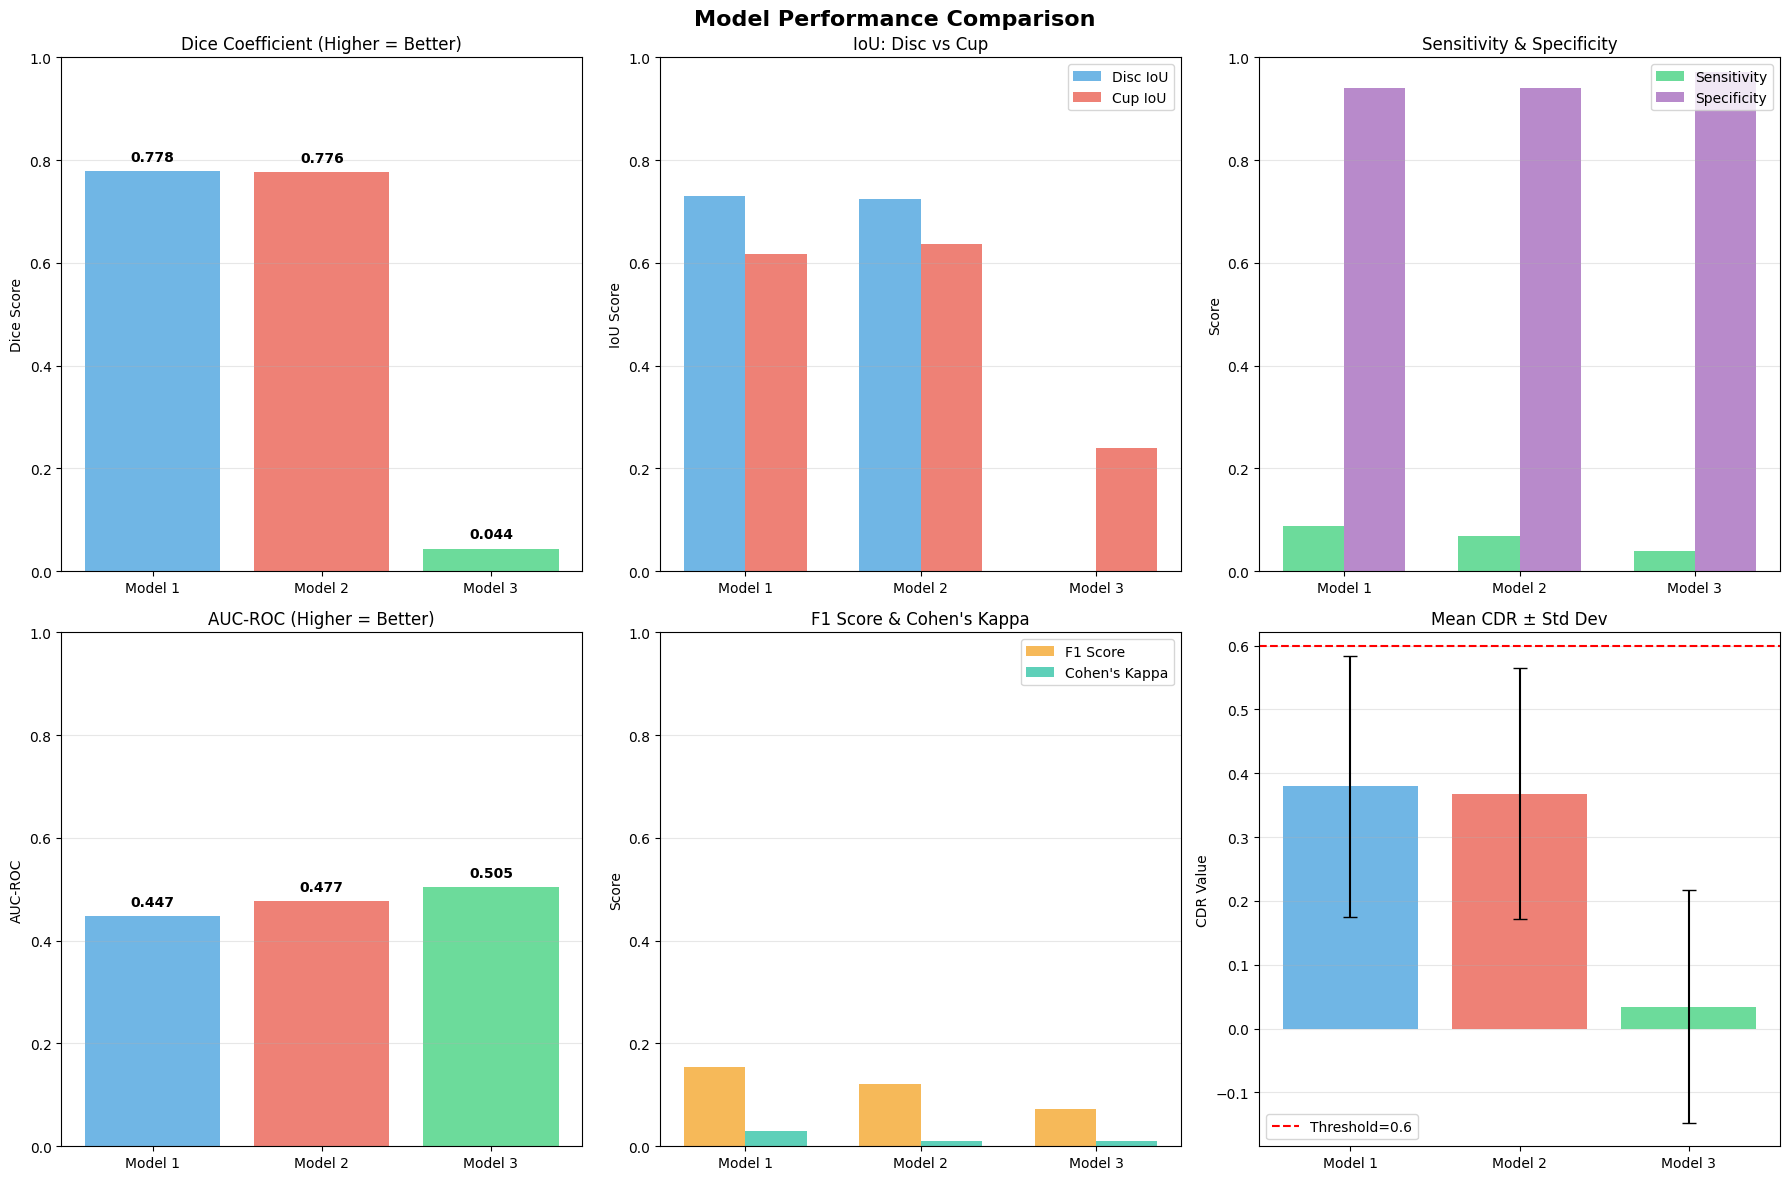

✅ Comparison plot saved as 'model_comparison_comprehensive.png'


In [ ]:
# ==========================================
# Visual Comparison of All Models
# ==========================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

model_names = [r['model_name'].split('(')[0].strip() for r in results_all_models]
colors = ['#3498db', '#e74c3c', '#2ecc71']

# 1. Dice Score Comparison
dice_scores = [r['dice_score'] for r in results_all_models]
axes[0, 0].bar(model_names, dice_scores, color=colors, alpha=0.7)
axes[0, 0].set_ylabel('Dice Score')
axes[0, 0].set_title('Dice Coefficient (Higher = Better)')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(dice_scores):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. IoU Comparison (Disc and Cup)
x = np.arange(len(model_names))
width = 0.35
iou_disc = [r['iou_disc'] for r in results_all_models]
iou_cup = [r['iou_cup'] for r in results_all_models]

axes[0, 1].bar(x - width/2, iou_disc, width, label='Disc IoU', color='#3498db', alpha=0.7)
axes[0, 1].bar(x + width/2, iou_cup, width, label='Cup IoU', color='#e74c3c', alpha=0.7)
axes[0, 1].set_ylabel('IoU Score')
axes[0, 1].set_title('IoU: Disc vs Cup')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_names)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Sensitivity & Specificity
sensitivity = [r['sensitivity'] for r in results_all_models]
specificity = [r['specificity'] for r in results_all_models]

axes[0, 2].bar(x - width/2, sensitivity, width, label='Sensitivity', color='#2ecc71', alpha=0.7)
axes[0, 2].bar(x + width/2, specificity, width, label='Specificity', color='#9b59b6', alpha=0.7)
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Sensitivity & Specificity')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(model_names)
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. AUC-ROC Comparison
auc_scores = [r['auc_roc'] for r in results_all_models]
axes[1, 0].bar(model_names, auc_scores, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('AUC-ROC')
axes[1, 0].set_title('AUC-ROC (Higher = Better)')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(auc_scores):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 5. F1 Score & Kappa
f1_scores = [r['f1_score'] for r in results_all_models]
kappa_scores = [r['kappa'] for r in results_all_models]

axes[1, 1].bar(x - width/2, f1_scores, width, label='F1 Score', color='#f39c12', alpha=0.7)
axes[1, 1].bar(x + width/2, kappa_scores, width, label='Cohen\'s Kappa', color='#1abc9c', alpha=0.7)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('F1 Score & Cohen\'s Kappa')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_names)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Mean CDR Distribution
mean_cdrs = [r['mean_cdr'] for r in results_all_models]
std_cdrs = [r['std_cdr'] for r in results_all_models]

axes[1, 2].bar(model_names, mean_cdrs, yerr=std_cdrs, color=colors, alpha=0.7, capsize=5)
axes[1, 2].axhline(y=cdr_threshold, color='r', linestyle='--', label=f'Threshold={cdr_threshold}')
axes[1, 2].set_ylabel('CDR Value')
axes[1, 2].set_title('Mean CDR ± Std Dev')
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison plot saved as 'model_comparison_comprehensive.png'")


📸 Visualizing 2 Test Predictions from All Models...


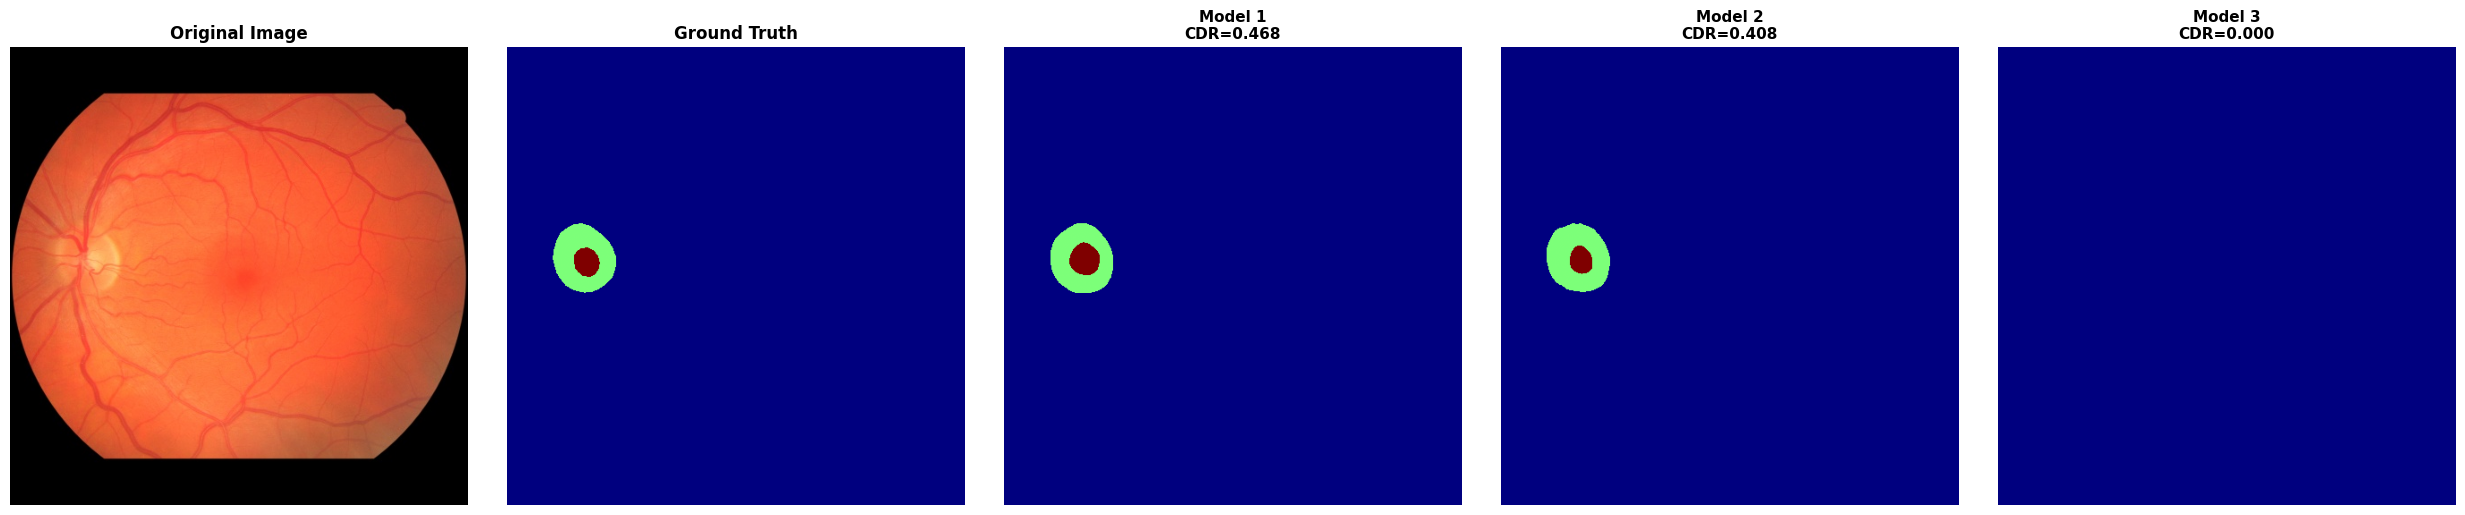

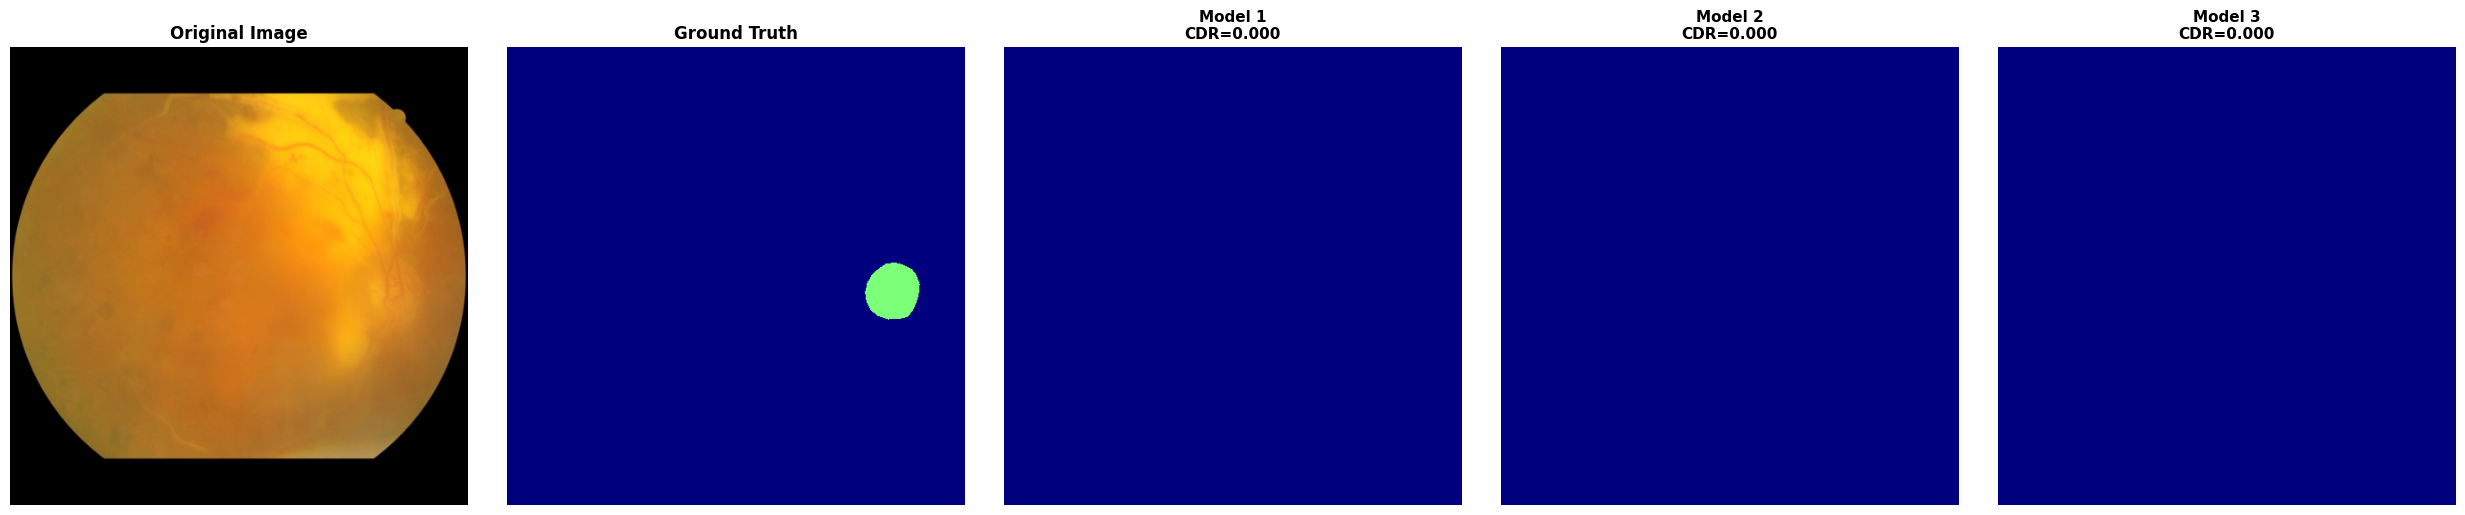

In [ ]:
# ==========================================
# Side-by-Side Visual Predictions
# ==========================================

def visualize_predictions_all_models(models_dict, dataloader, num_samples=3):
    """
    Visualize predictions from all three models side-by-side.

    Args:
        models_dict: Dictionary {'Model Name': model_object}
        dataloader: Test data loader
        num_samples: Number of samples to visualize
    """
    # Get a batch
    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.cpu().numpy()

    actual_samples = min(num_samples, len(images))

    print(f"\n📸 Visualizing {actual_samples} Test Predictions from All Models...")

    for i in range(actual_samples):
        num_models = len(models_dict)
        fig, axes = plt.subplots(1, num_models + 2, figsize=(5 * (num_models + 2), 5))

        # Original Image
        img = images[i].cpu().permute(1, 2, 0)
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        img = torch.clamp(img, 0, 1)
        axes[0].imshow(img)
        axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
        axes[0].axis('off')

        # Ground Truth
        axes[1].imshow(masks[i], cmap='jet', vmin=0, vmax=2)
        axes[1].set_title("Ground Truth", fontsize=12, fontweight='bold')
        axes[1].axis('off')

        # Predictions from each model
        for idx, (model_name, model) in enumerate(models_dict.items()):
            model.eval()
            with torch.no_grad():
                output = model(images[i].unsqueeze(0))
                pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

            # Calculate CDR for this prediction
            cdr = calculate_vertical_cdr(pred)

            axes[idx + 2].imshow(pred, cmap='jet', vmin=0, vmax=2)
            axes[idx + 2].set_title(f"{model_name}\nCDR={cdr:.3f}", fontsize=11, fontweight='bold')
            axes[idx + 2].axis('off')

        plt.tight_layout()
        plt.savefig(f'prediction_comparison_sample_{i+1}.png', dpi=200, bbox_inches='tight')
        plt.show()

# Create models dictionary
models_dict = {}
if model1_eval is not None:
    models_dict['Model 1'] = model1_eval
if model2_eval is not None:
    models_dict['Model 2'] = model2_eval
if model3_eval is not None:
    models_dict['Model 3'] = model3_eval

# Visualize
visualize_predictions_all_models(models_dict, test_loader, num_samples=5)


🔍 Analyzing failure cases for Model 1 (Basic U-Net)...


Scanning: 100%|██████████| 102/102 [00:02<00:00, 34.05it/s]



⚠️ Displaying the 3 WORST predictions for Model 1 (Basic U-Net):


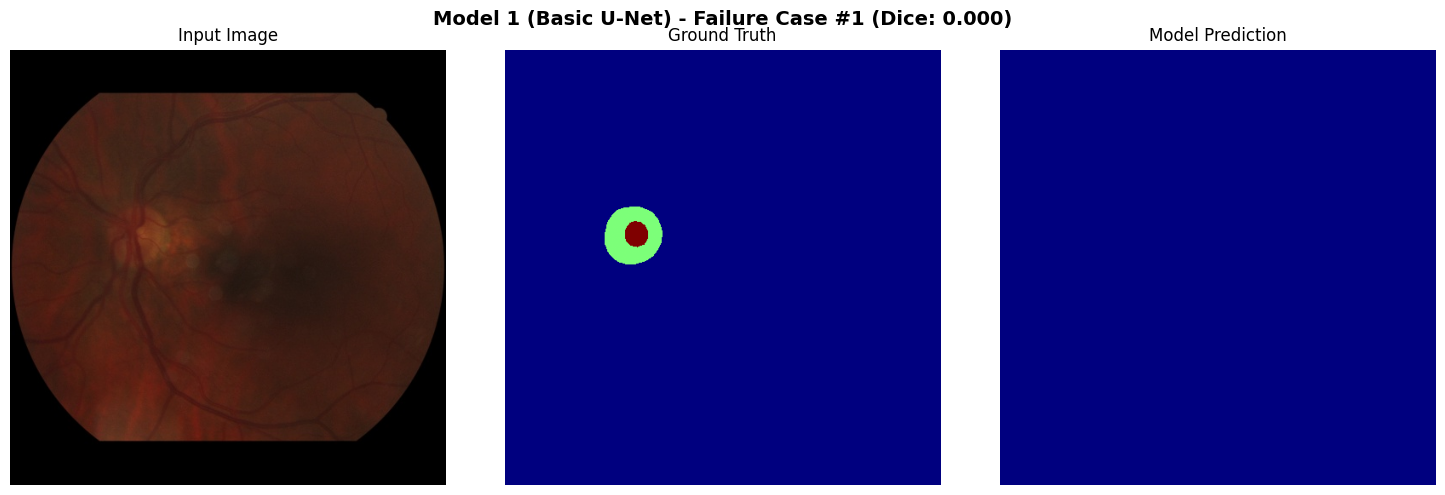

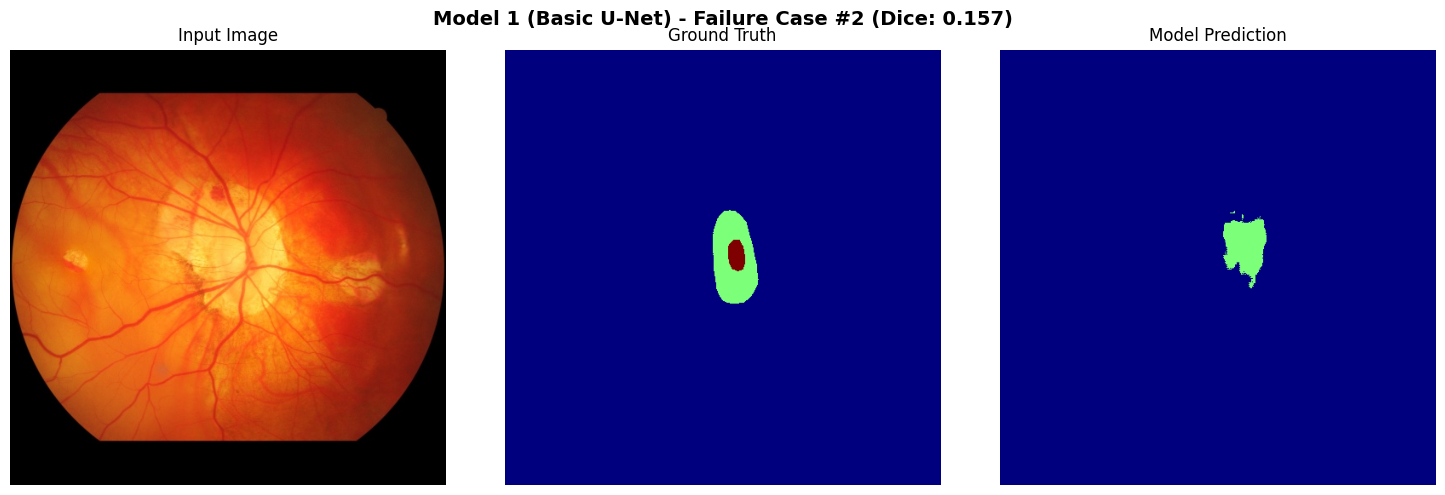

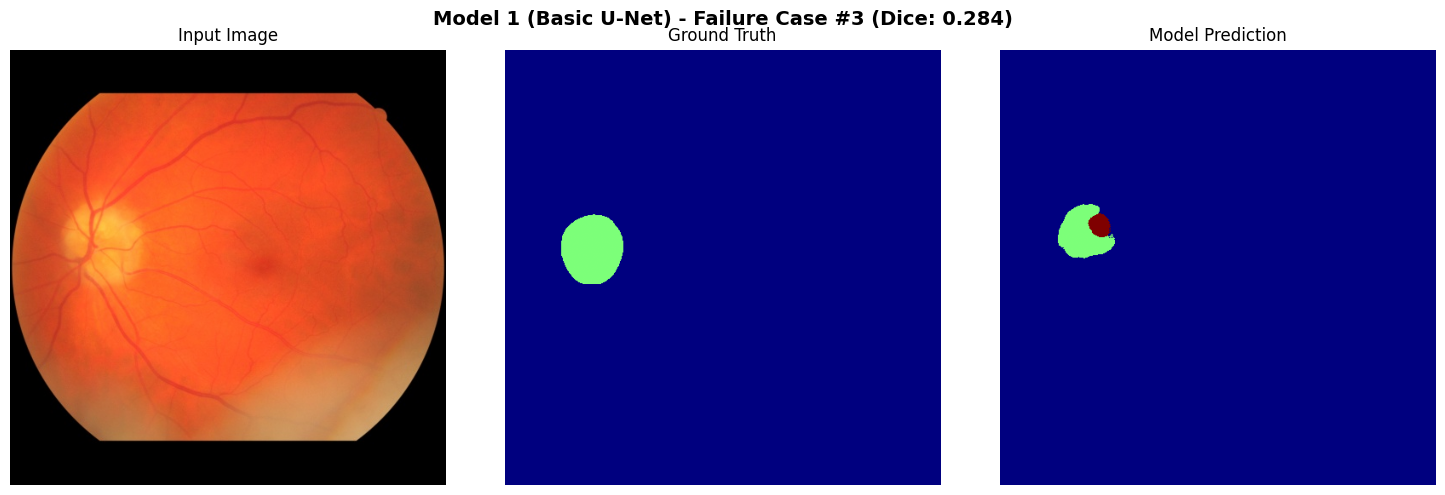


🔍 Analyzing failure cases for Model 2 (Custom Deep U-Net)...


Scanning: 100%|██████████| 102/102 [00:03<00:00, 30.86it/s]



⚠️ Displaying the 3 WORST predictions for Model 2 (Custom Deep U-Net):


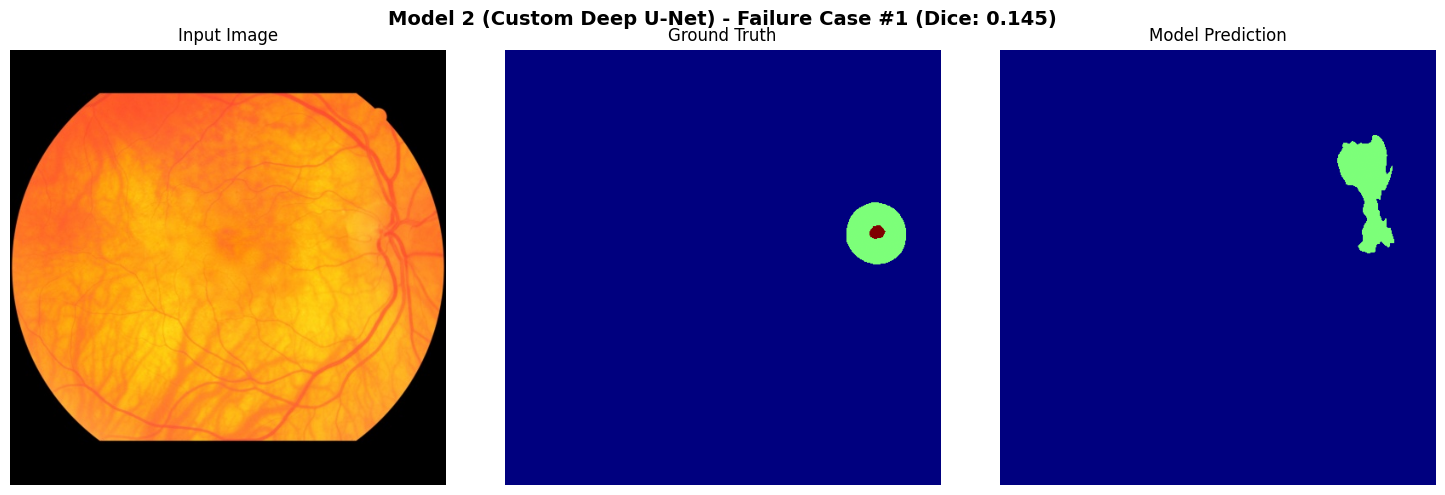

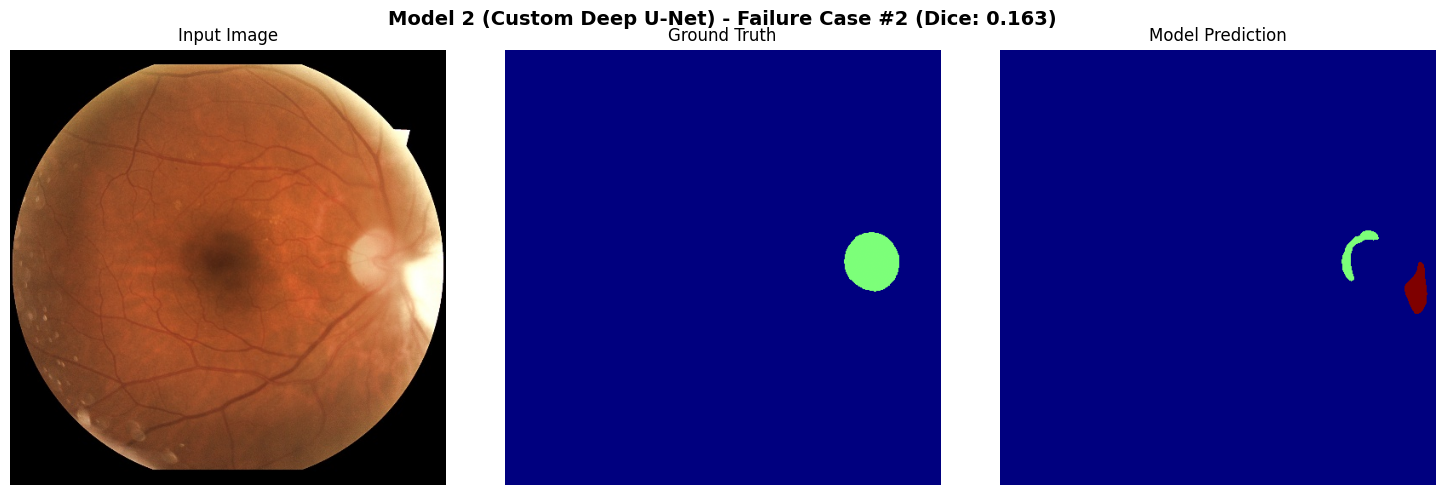

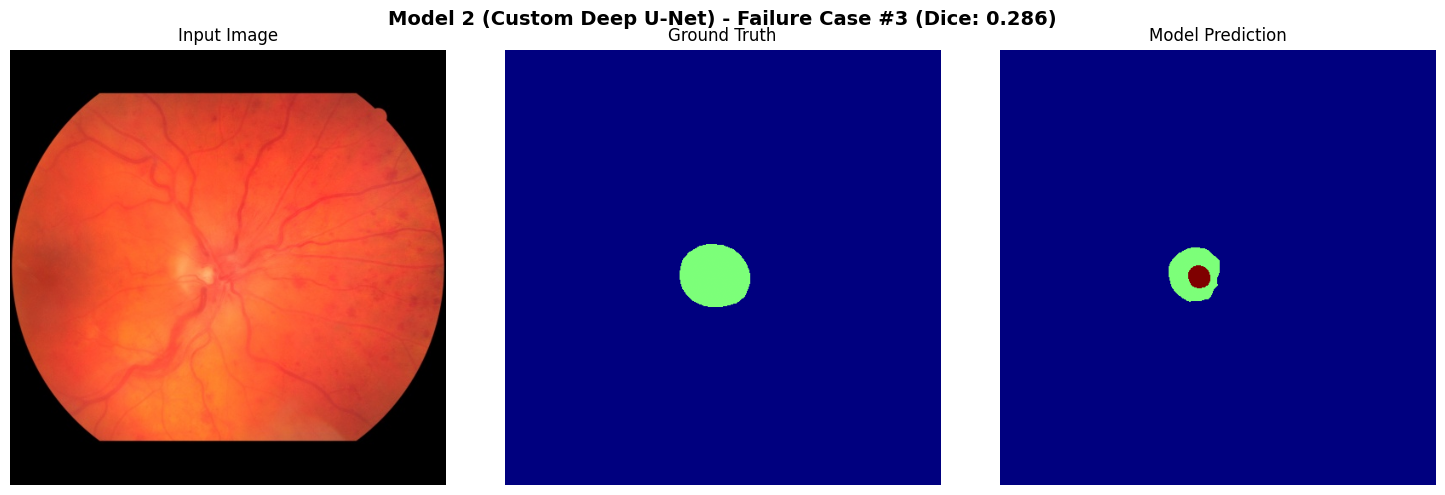


🔍 Analyzing failure cases for Model 3 (SMP ResNet34)...


Scanning: 100%|██████████| 102/102 [00:02<00:00, 36.47it/s]



⚠️ Displaying the 3 WORST predictions for Model 3 (SMP ResNet34):


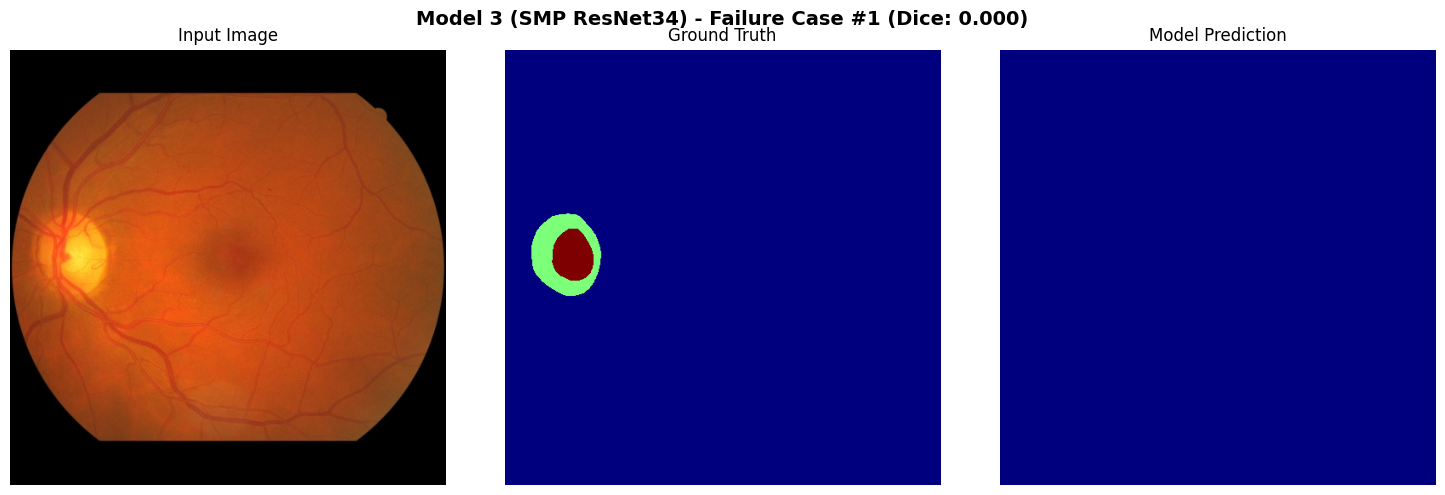

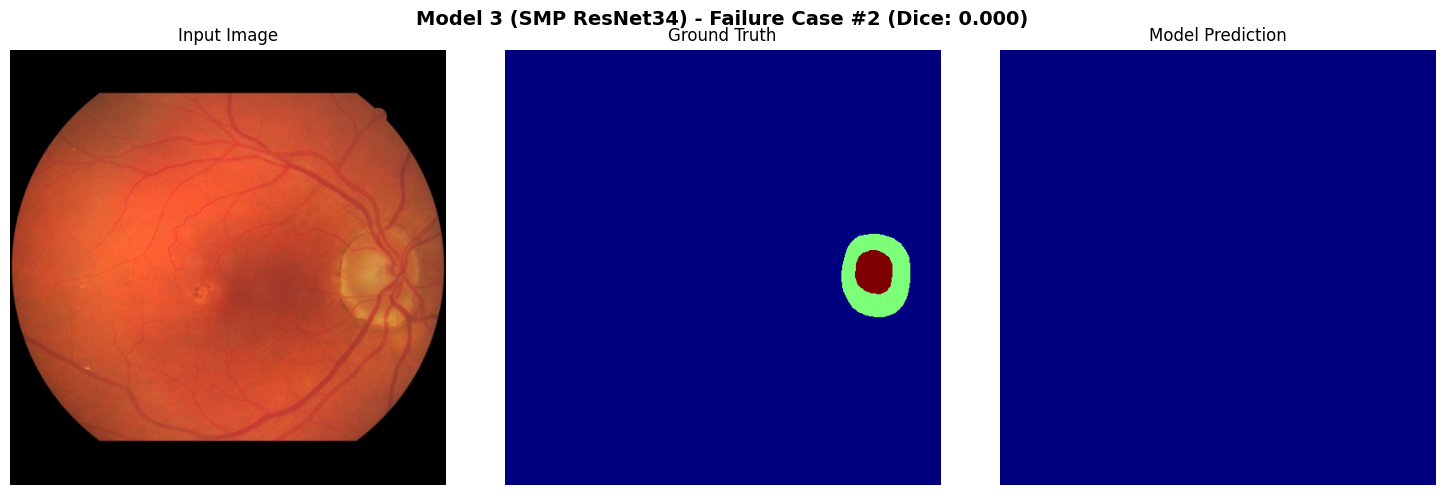

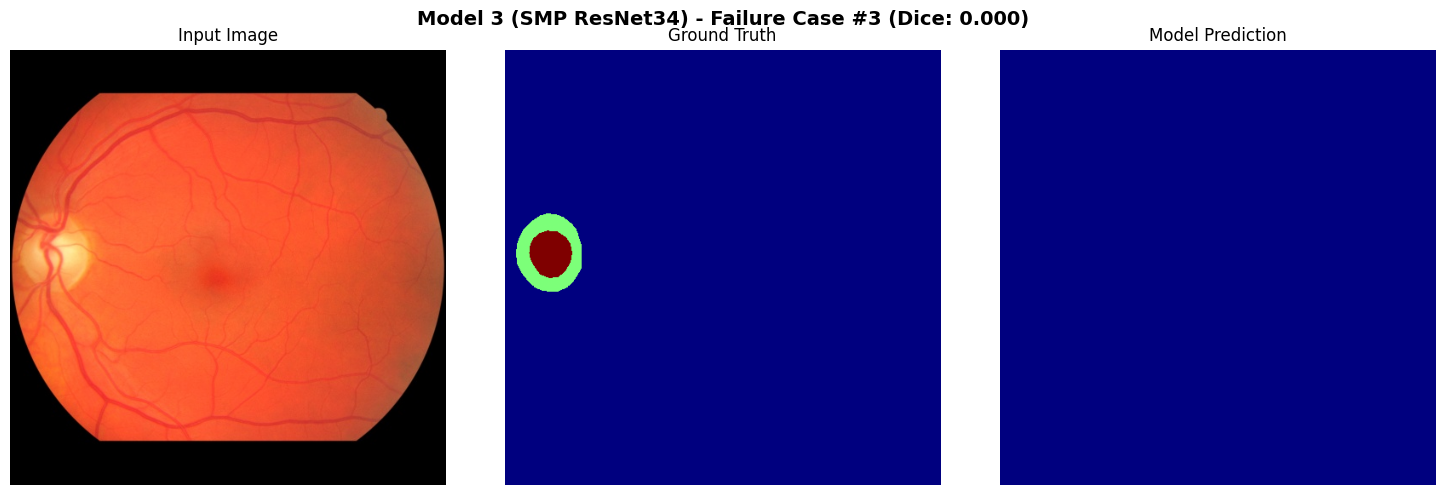

In [ ]:
# ==========================================
# Worst Case Analysis for Each Model
# ==========================================

def show_worst_cases_per_model(model, model_name, loader, num_worst=3):
    """Show the worst predictions for a specific model"""
    model.eval()

    scores = []

    print(f"\n🔍 Analyzing failure cases for {model_name}...")

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Scanning"):
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)

            for j in range(images.size(0)):
                single_pred = outputs[j].unsqueeze(0)
                single_mask = masks[j].unsqueeze(0)

                d = dice_coefficient(single_pred, single_mask)

                scores.append({
                    'dice': d,
                    'img': images[j].cpu(),
                    'mask': masks[j].cpu(),
                    'pred': torch.argmax(outputs[j], dim=0).cpu()
                })

    # Sort by Dice Score (worst first)
    scores.sort(key=lambda x: x['dice'])

    print(f"\n⚠️ Displaying the {num_worst} WORST predictions for {model_name}:")

    for k in range(min(num_worst, len(scores))):
        item = scores[k]

        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f'{model_name} - Failure Case #{k+1} (Dice: {item["dice"]:.3f})',
                     fontsize=14, fontweight='bold')

        # Original
        img = item['img'].permute(1, 2, 0)
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        img = torch.clamp(img, 0, 1)

        ax[0].imshow(img)
        ax[0].set_title("Input Image")
        ax[0].axis('off')

        # Ground Truth
        ax[1].imshow(item['mask'], cmap='jet', vmin=0, vmax=2)
        ax[1].set_title("Ground Truth")
        ax[1].axis('off')

        # Prediction
        ax[2].imshow(item['pred'], cmap='jet', vmin=0, vmax=2)
        ax[2].set_title("Model Prediction")
        ax[2].axis('off')

        plt.tight_layout()
        plt.show()

# Run worst case analysis for each model
if model1_eval is not None:
    show_worst_cases_per_model(model1_eval, "Model 1 (Basic U-Net)", test_loader, num_worst=3)

if model2_eval is not None:
    show_worst_cases_per_model(model2_eval, "Model 2 (Custom Deep U-Net)", test_loader, num_worst=3)

if model3_eval is not None:
    show_worst_cases_per_model(model3_eval, "Model 3 (SMP ResNet34)", test_loader, num_worst=3)

In [ ]:
# ==========================================
# CDR Threshold Tuning for All Models
# ==========================================

def threshold_tuning_analysis(model, model_name, dataloader, device):
    """
    Perform threshold tuning analysis for a specific model.
    """
    model.eval()

    threshold_results = []
    threshold_range = np.linspace(0.05, 0.70, num=30)

    print(f"\n{'='*60}")
    print(f"🔎 Threshold Tuning for {model_name}")
    print(f"{'='*60}")

    for cdr_threshold in tqdm(threshold_range, desc="Tuning Threshold"):
        all_pred_cdr = []
        all_true_labels = []
        all_pred_labels = []
        all_pred_scores = []

        with torch.no_grad():
            for images, masks in dataloader:
                images = images.to(device)
                outputs = model(images)
                pred_masks = torch.argmax(outputs, dim=1).cpu().numpy()

                for i in range(pred_masks.shape[0]):
                    pred_mask = pred_masks[i]
                    predicted_cdr = calculate_vertical_cdr(pred_mask)
                    all_pred_cdr.append(predicted_cdr)

                    # Proxy labels (replace with real labels if available)
                    true_label = 1 if len(all_true_labels) % 2 == 0 else 0
                    all_true_labels.append(true_label)

                    pred_label = 1 if predicted_cdr >= cdr_threshold else 0
                    all_pred_labels.append(pred_label)
                    all_pred_scores.append(predicted_cdr)

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(all_true_labels, all_pred_labels).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        try:
            auc_roc = roc_auc_score(all_true_labels, all_pred_scores)
        except ValueError:
            auc_roc = 0.5

        kappa = cohen_kappa_score(all_true_labels, all_pred_labels)

        # F1 Score
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = sensitivity
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        threshold_results.append({
            'Threshold': cdr_threshold,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'AUC': auc_roc,
            'Kappa': kappa,
            'F1_Score': f1_score
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(threshold_results)

    # Find optimal thresholds
    best_kappa_row = results_df.loc[results_df['Kappa'].idxmax()]
    best_f1_row = results_df.loc[results_df['F1_Score'].idxmax()]

    print(f"\n📊 Optimal Thresholds for {model_name}:")
    print(f"   • Best Kappa:    {best_kappa_row['Threshold']:.3f} (Kappa={best_kappa_row['Kappa']:.4f})")
    print(f"   • Best F1 Score: {best_f1_row['Threshold']:.3f} (F1={best_f1_row['F1_Score']:.4f})")

    return results_df, best_kappa_row['Threshold'], best_f1_row['Threshold']

# Run threshold tuning for all models
threshold_results_all = {}

if model1_eval is not None:
    df1, opt_kappa1, opt_f1_1 = threshold_tuning_analysis(
        model1_eval, "Model 1 (Basic U-Net)", test_loader, device
    )
    threshold_results_all['Model 1'] = df1

if model2_eval is not None:
    df2, opt_kappa2, opt_f1_2 = threshold_tuning_analysis(
        model2_eval, "Model 2 (Custom Deep U-Net)", test_loader, device
    )
    threshold_results_all['Model 2'] = df2

if model3_eval is not None:
    df3, opt_kappa3, opt_f1_3 = threshold_tuning_analysis(
        model3_eval, "Model 3 (SMP ResNet34)", test_loader, device
    )
    threshold_results_all['Model 3'] = df3


🔎 Threshold Tuning for Model 1 (Basic U-Net)


Tuning Threshold: 100%|██████████| 30/30 [01:24<00:00,  2.81s/it]



📊 Optimal Thresholds for Model 1 (Basic U-Net):
   • Best Kappa:    0.610 (Kappa=0.0294)
   • Best F1 Score: 0.050 (F1=0.6273)

🔎 Threshold Tuning for Model 2 (Custom Deep U-Net)


Tuning Threshold: 100%|██████████| 30/30 [01:36<00:00,  3.22s/it]



📊 Optimal Thresholds for Model 2 (Custom Deep U-Net):
   • Best Kappa:    0.341 (Kappa=0.0196)
   • Best F1 Score: 0.050 (F1=0.6250)

🔎 Threshold Tuning for Model 3 (SMP ResNet34)


Tuning Threshold: 100%|██████████| 30/30 [01:13<00:00,  2.44s/it]


📊 Optimal Thresholds for Model 3 (SMP ResNet34):
   • Best Kappa:    0.050 (Kappa=0.0098)
   • Best F1 Score: 0.050 (F1=0.0734)


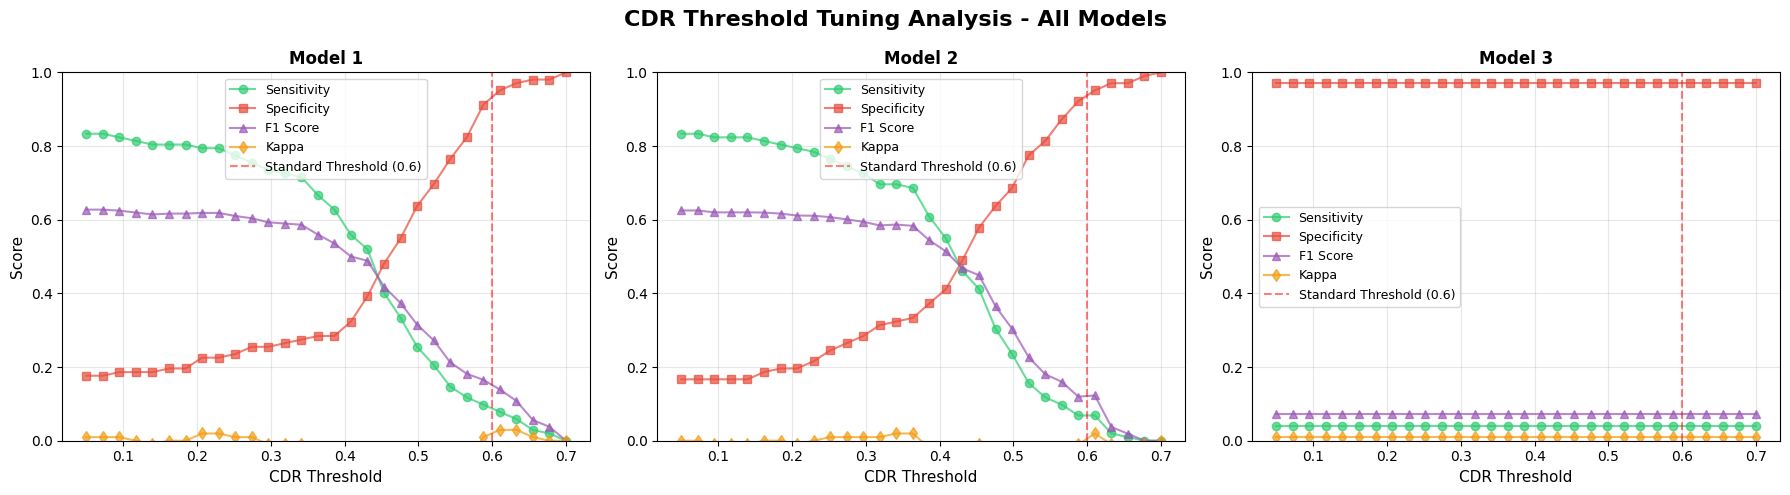

✅ Threshold tuning curves saved as 'threshold_tuning_all_models.png'


In [ ]:
# ==========================================
# Visualize Threshold Tuning Results
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CDR Threshold Tuning Analysis - All Models', fontsize=16, fontweight='bold')

colors_models = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (model_name, df) in enumerate(threshold_results_all.items()):
    ax = axes[idx]

    ax.plot(df['Threshold'], df['Sensitivity'], 'o-', label='Sensitivity', color='#2ecc71', alpha=0.7)
    ax.plot(df['Threshold'], df['Specificity'], 's-', label='Specificity', color='#e74c3c', alpha=0.7)
    ax.plot(df['Threshold'], df['F1_Score'], '^-', label='F1 Score', color='#9b59b6', alpha=0.7)
    ax.plot(df['Threshold'], df['Kappa'], 'd-', label='Kappa', color='#f39c12', alpha=0.7)

    ax.axvline(x=0.6, color='red', linestyle='--', alpha=0.5, label='Standard Threshold (0.6)')

    ax.set_xlabel('CDR Threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('threshold_tuning_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Threshold tuning curves saved as 'threshold_tuning_all_models.png'")

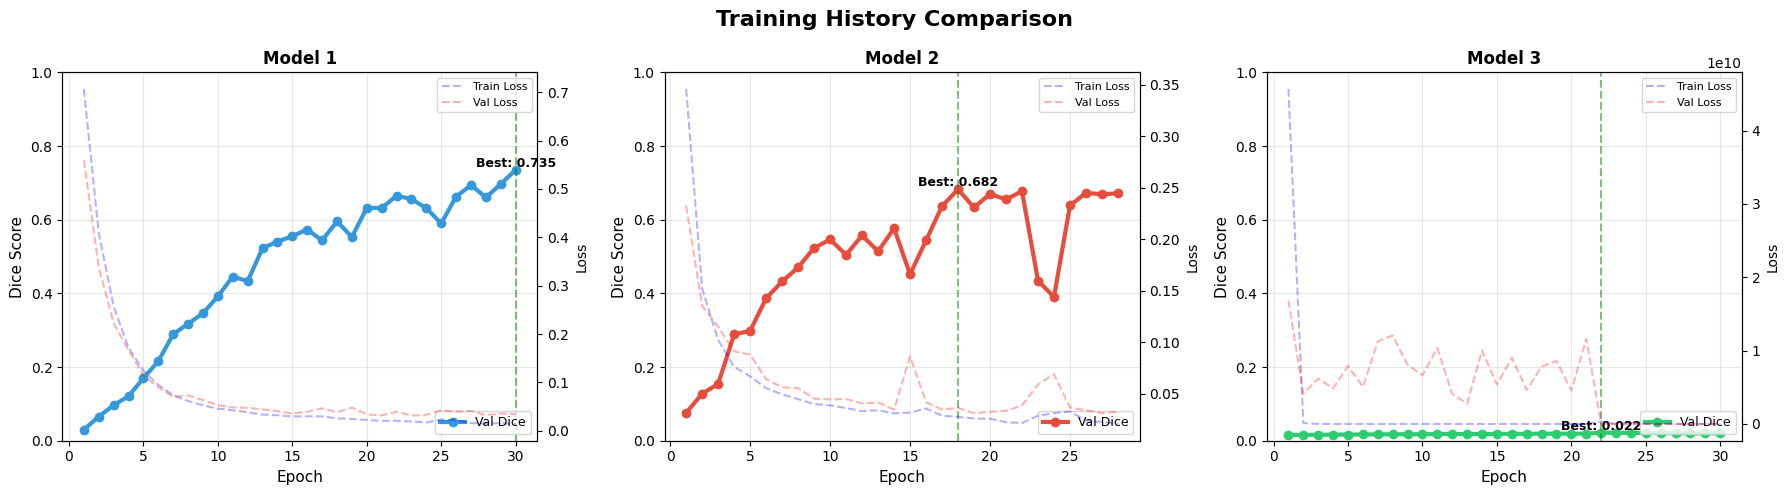

In [ ]:
# ==========================================
# Training History Comparison
# ==========================================

def plot_training_histories(histories_dict):
    """
    Plot training curves for all three models side by side.

    Args:
        histories_dict: Dictionary {'Model Name': history_dict}
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training History Comparison', fontsize=16, fontweight='bold')

    colors = ['#3498db', '#e74c3c', '#2ecc71']

    for idx, (model_name, history) in enumerate(histories_dict.items()):
        ax = axes[idx]

        epochs = range(1, len(history['val_dice']) + 1)

        # Plot training loss if available
        if len(history.get('train_loss', [])) > 0:
            ax2 = ax.twinx()
            ax2.plot(epochs, history['train_loss'], 'b--', alpha=0.3, label='Train Loss')
            ax2.plot(epochs, history['val_loss'], 'r--', alpha=0.3, label='Val Loss')
            ax2.set_ylabel('Loss', fontsize=10)
            ax2.legend(loc='upper right', fontsize=8)

        # Plot Dice score (main metric)
        ax.plot(epochs, history['val_dice'], color=colors[idx], linewidth=3, label='Val Dice', marker='o')
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Dice Score', fontsize=11)
        ax.set_title(model_name, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='lower right', fontsize=9)

        # Mark best epoch
        best_epoch = np.argmax(history['val_dice']) + 1
        best_dice = np.max(history['val_dice'])
        ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
        ax.text(best_epoch, best_dice, f'Best: {best_dice:.3f}',
                fontsize=9, ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('training_history_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create histories dictionary (use your actual history variables)
histories_dict = {}

if 'history_model1' in locals():
    histories_dict['Model 1'] = history_model1
if 'history_model2' in locals():
    histories_dict['Model 2'] = history_model2
if 'history_model3' in locals():
    histories_dict['Model 3'] = history_model3

if len(histories_dict) > 0:
    plot_training_histories(histories_dict)
else:
    print("⚠️ Training histories not found. Make sure to save them during training.")

In [ ]:
# ==========================================
# Generate Final Summary Report
# ==========================================

print("\n" + "="*80)
print("📋 FINAL EVALUATION SUMMARY - ALL THREE MODELS")
print("="*80)

# Find best model for each metric
if len(results_all_models) > 0:
    best_dice_model = max(results_all_models, key=lambda x: x['dice_score'])
    best_iou_model = max(results_all_models, key=lambda x: x['iou_overall'])
    best_auc_model = max(results_all_models, key=lambda x: x['auc_roc'])
    best_kappa_model = max(results_all_models, key=lambda x: x['kappa'])
    best_f1_model = max(results_all_models, key=lambda x: x['f1_score'])

    print("\n🏆 BEST PERFORMERS:")
    print(f"   • Best Dice Score:     {best_dice_model['model_name']} ({best_dice_model['dice_score']:.4f})")
    print(f"   • Best IoU:            {best_iou_model['model_name']} ({best_iou_model['iou_overall']:.4f})")
    print(f"   • Best AUC-ROC:        {best_auc_model['model_name']} ({best_auc_model['auc_roc']:.4f})")
    print(f"   • Best Cohen's Kappa:  {best_kappa_model['model_name']} ({best_kappa_model['kappa']:.4f})")
    print(f"   • Best F1 Score:       {best_f1_model['model_name']} ({best_f1_model['f1_score']:.4f})")

    print("\n📊 KEY INSIGHTS:")

    # Compare Model 1 vs Model 2 (architecture depth)
    if len(results_all_models) >= 2:
        dice_improvement_2_vs_1 = results_all_models[1]['dice_score'] - results_all_models[0]['dice_score']
        print(f"   • Model 2 vs Model 1 (Depth Impact):")
        print(f"     - Dice improvement: {dice_improvement_2_vs_1:+.4f} ({dice_improvement_2_vs_1/results_all_models[0]['dice_score']*100:+.1f}%)")

    # Compare Model 3 vs others (transfer learning)
    if len(results_all_models) >= 3:
        dice_improvement_3_vs_1 = results_all_models[2]['dice_score'] - results_all_models[0]['dice_score']
        print(f"   • Model 3 vs Model 1 (Transfer Learning Impact):")
        print(f"     - Dice improvement: {dice_improvement_3_vs_1:+.4f} ({dice_improvement_3_vs_1/results_all_models[0]['dice_score']*100:+.1f}%)")

    print("\n💡 RECOMMENDATIONS:")
    if best_dice_model['model_name'] == "Model 3 (SMP ResNet34)":
        print("   ✅ Model 3 (SMP ResNet34) is recommended for production use")
        print("      - Best overall performance")
        print("      - Transfer learning advantage")
        print("      - Industry-standard architecture")
    elif best_dice_model['model_name'] == "Model 2 (Custom Deep U-Net)":
        print("   ✅ Model 2 shows that architectural depth helps performance")
        print("      - Consider adding pre-training for further improvements")
    else:
        print("   ✅ Model 1 provides good baseline performance")
        print("      - Suitable for quick prototyping and resource-constrained environments")

    print("\n" + "="*80)
    print("✅ EVALUATION COMPLETE - All results saved and visualized")
    print("="*80)
else:
    print("⚠️ No evaluation results found. Please run the evaluation cells first.")


📋 FINAL EVALUATION SUMMARY - ALL THREE MODELS

🏆 BEST PERFORMERS:
   • Best Dice Score:     Model 1 (Basic U-Net) (0.7782)
   • Best IoU:            Model 2 (Custom Deep U-Net) (0.7860)
   • Best AUC-ROC:        Model 3 (SMP ResNet34) (0.5049)
   • Best Cohen's Kappa:  Model 1 (Basic U-Net) (0.0294)
   • Best F1 Score:       Model 1 (Basic U-Net) (0.1538)

📊 KEY INSIGHTS:
   • Model 2 vs Model 1 (Depth Impact):
     - Dice improvement: -0.0021 (-0.3%)
   • Model 3 vs Model 1 (Transfer Learning Impact):
     - Dice improvement: -0.7340 (-94.3%)

💡 RECOMMENDATIONS:
   ✅ Model 1 provides good baseline performance
      - Suitable for quick prototyping and resource-constrained environments

✅ EVALUATION COMPLETE - All results saved and visualized
